In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("E:/Datasets/breast_cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df.duplicated().sum()

0

In [7]:
df.shape

(569, 33)

In [8]:
df = df.drop(columns='Unnamed: 32')

### EDA

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


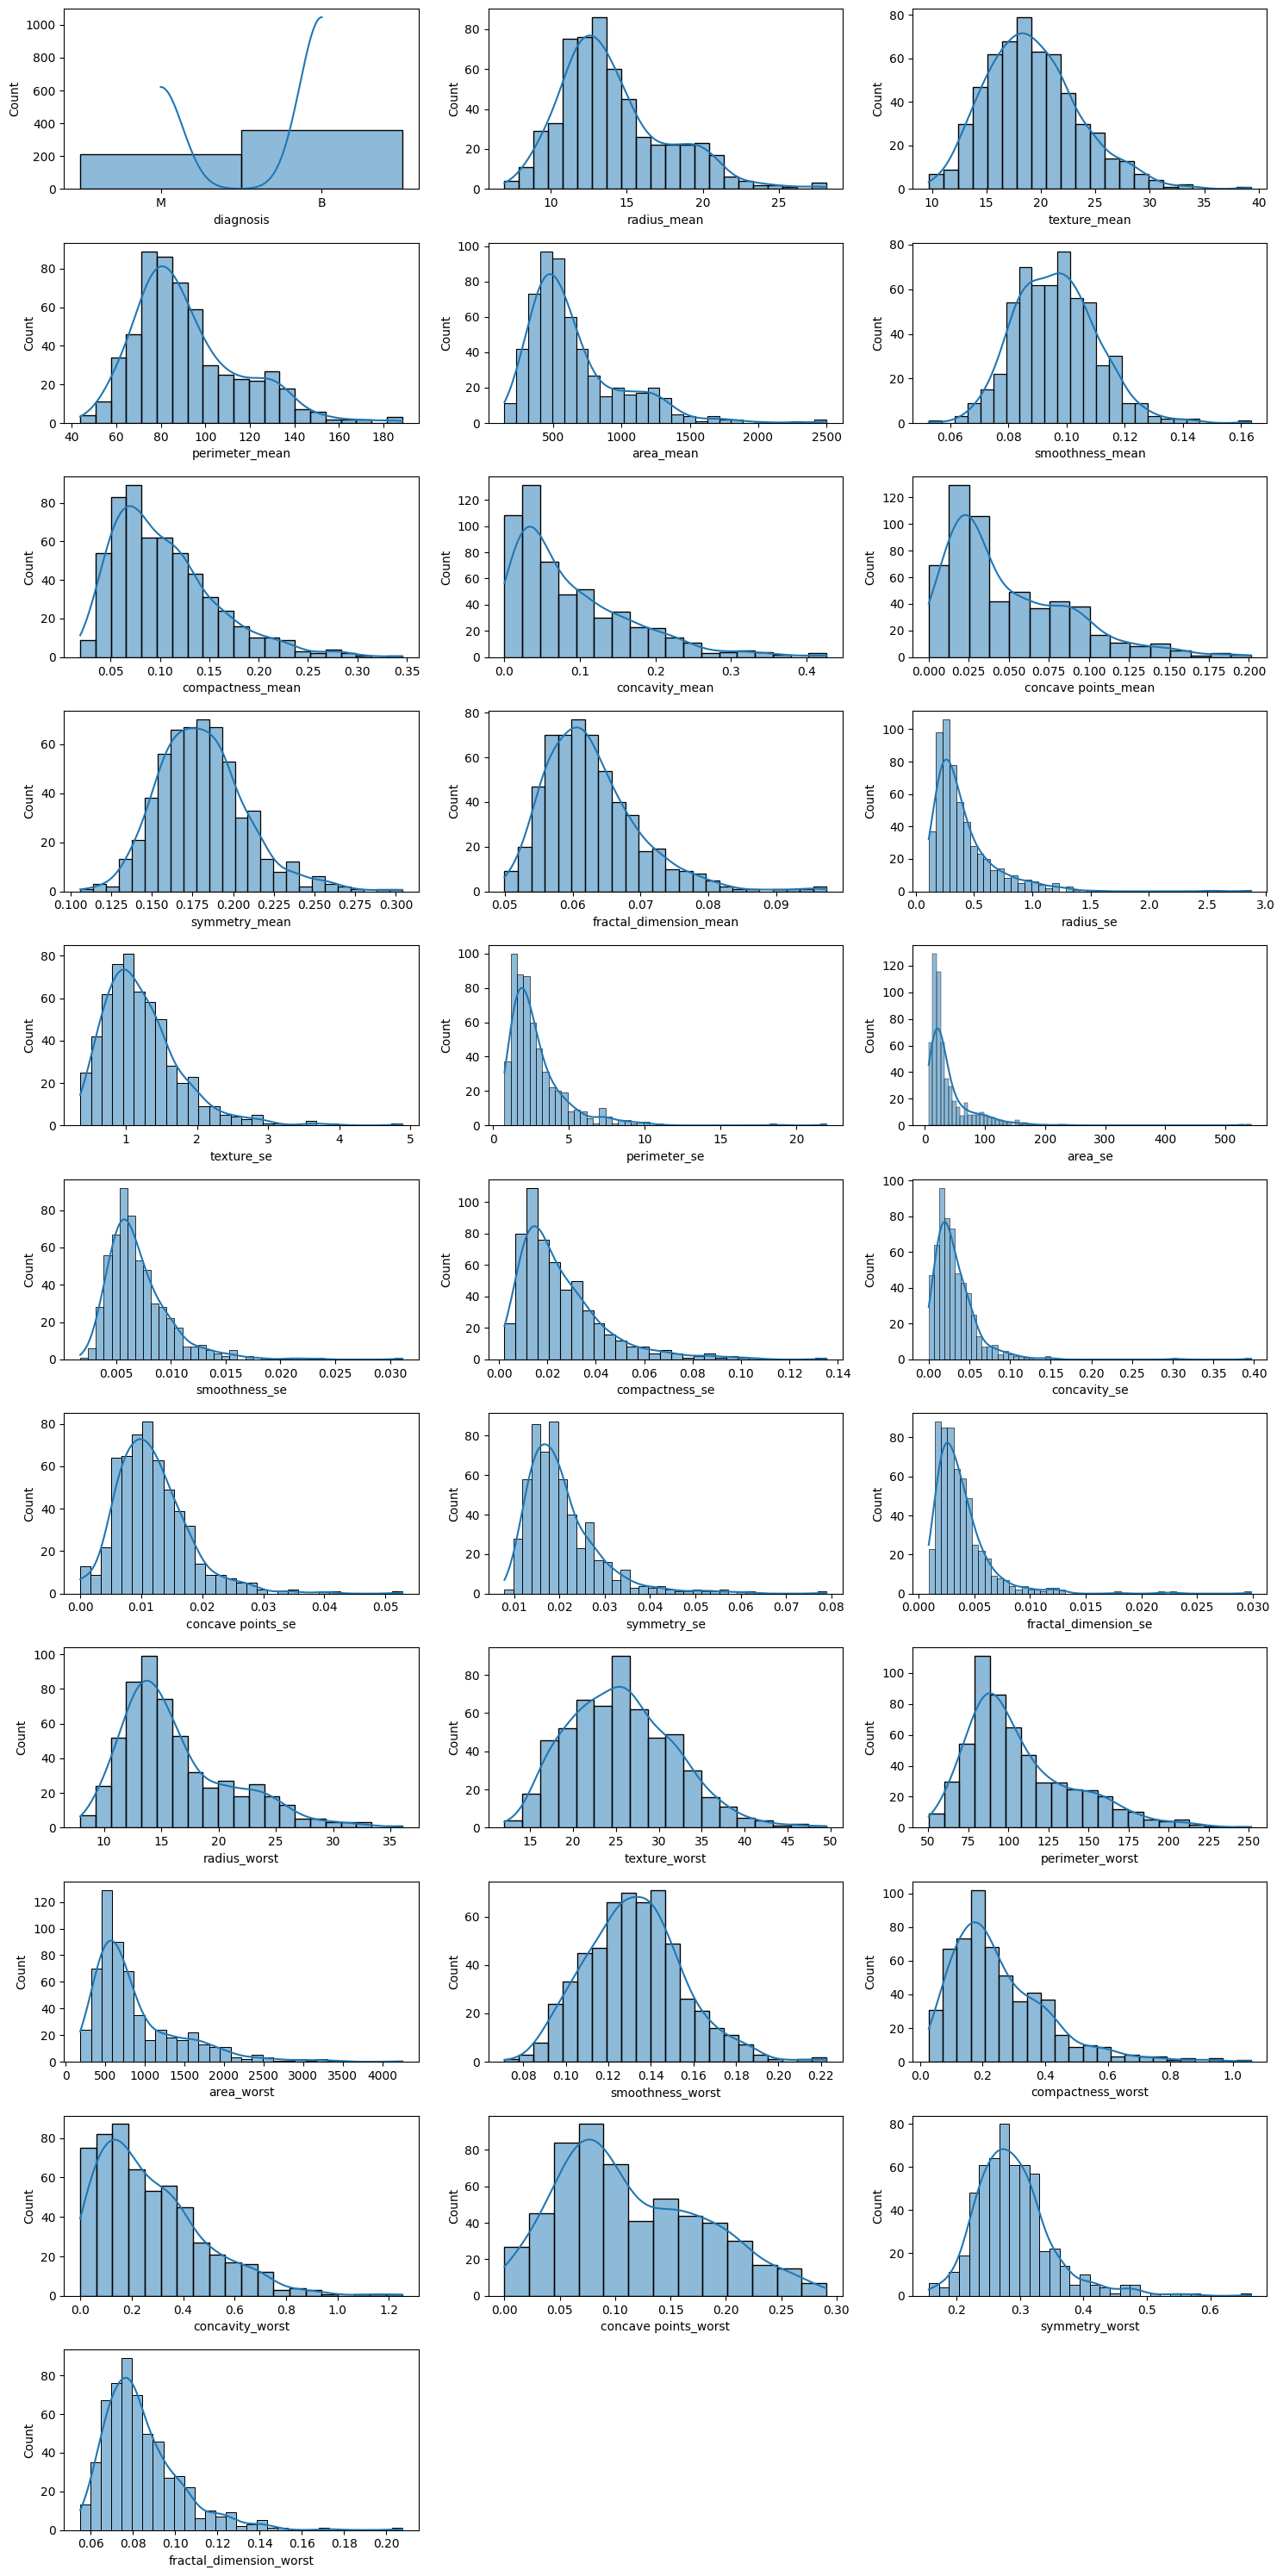

In [10]:
n = 1
plt.figure(figsize=(15, 30))
for i in df.drop(columns='id').columns:
    if n <= len(df.columns):
        ax = plt.subplot(11,3,n)
        sns.histplot(x=df[i], kde=True)
    n += 1

plt.tight_layout()
plt.show()

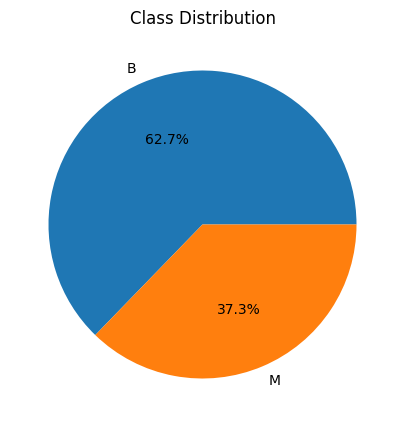

In [11]:
counts = df['diagnosis'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

####  Data is imbalcanced

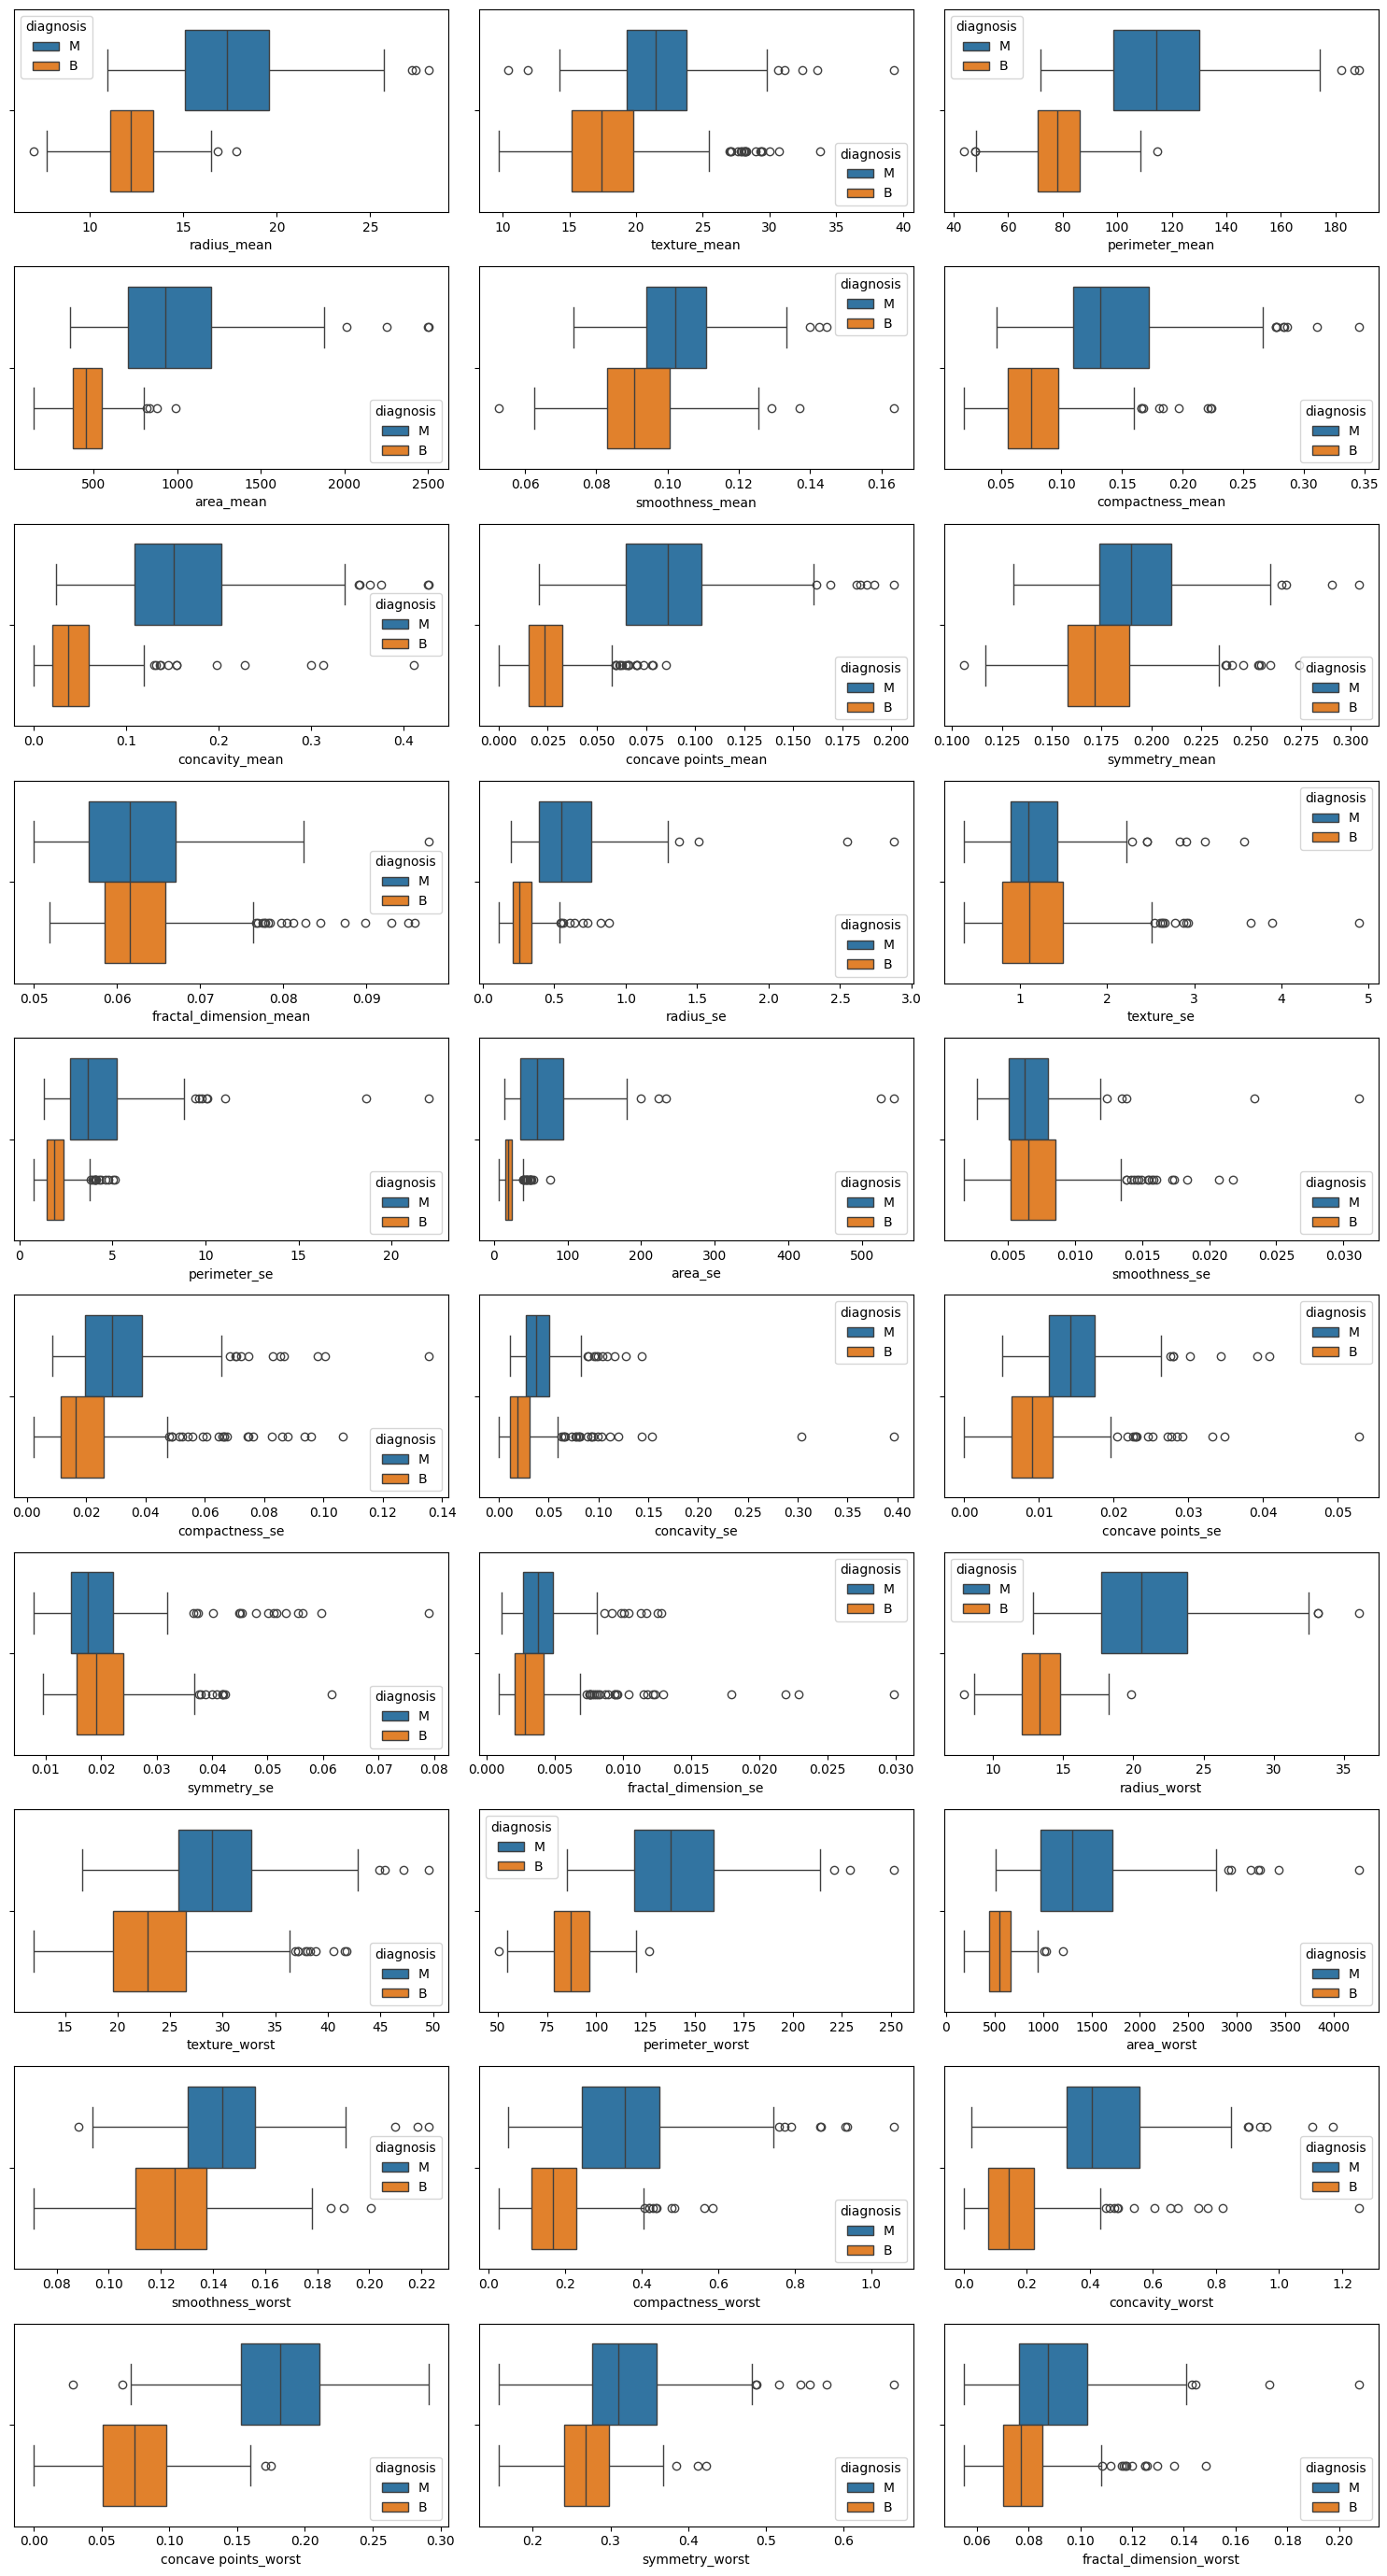

In [12]:
n = 1
plt.figure(figsize=(15, 30))
for i in df.drop(columns=['id', 'diagnosis']).columns:
    if n <= len(df.columns):
        ax = plt.subplot(11,3,n)
        sns.boxplot(data =df, x=i, hue='diagnosis')
    n += 1

plt.tight_layout()
plt.show()

### Feature Enggineering

In [13]:
df.drop(columns=['id', 'diagnosis']).corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


<Axes: >

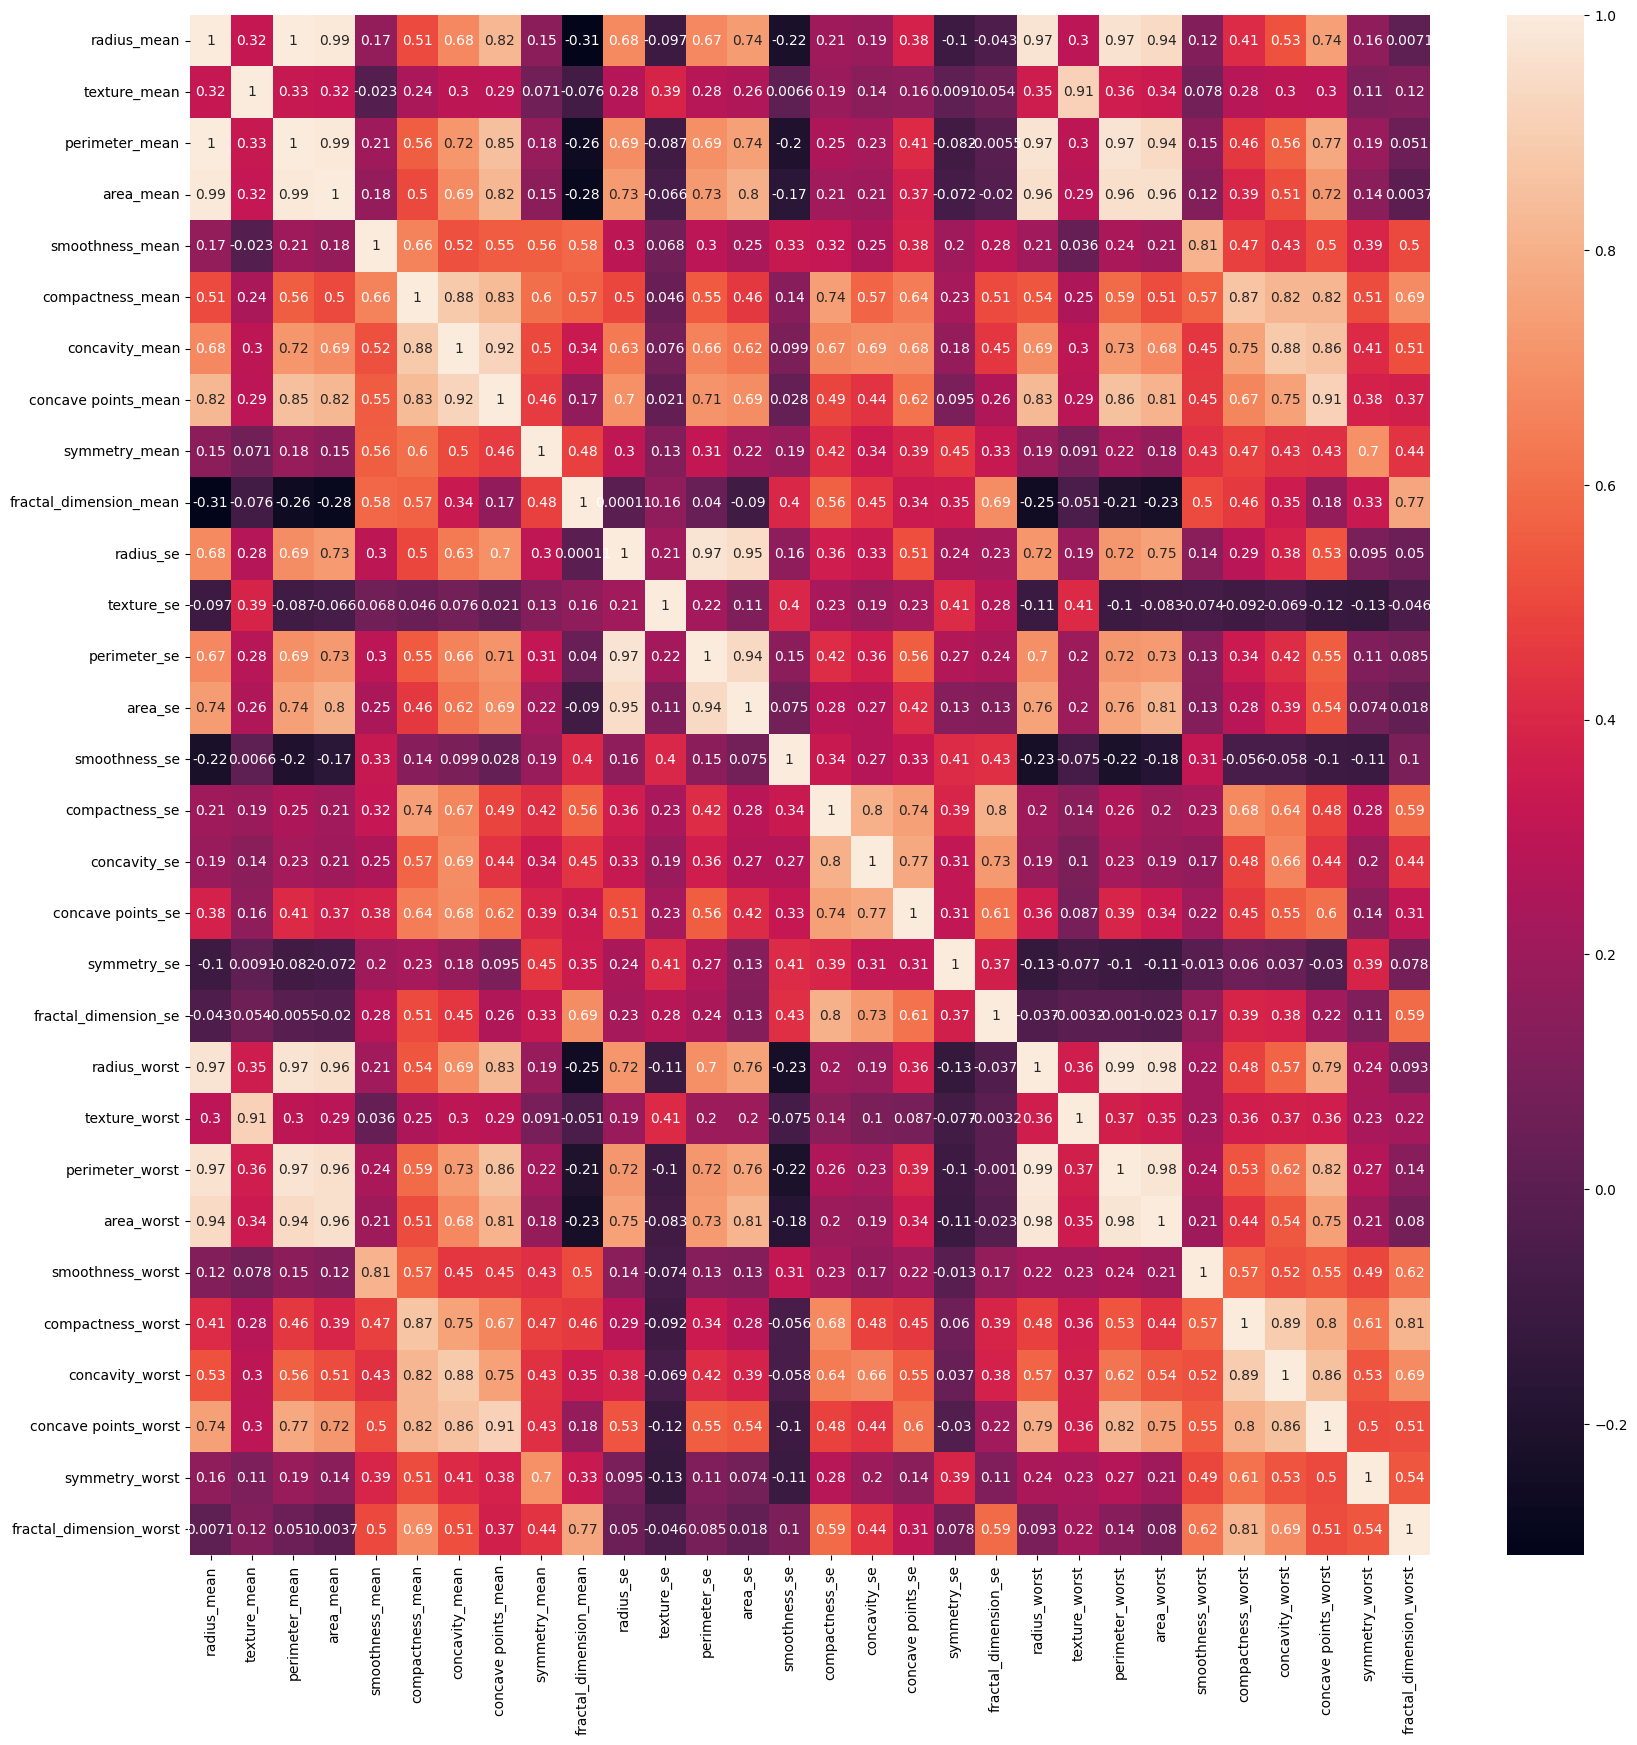

In [14]:
plt.figure(figsize=(20,20))
sns.heatmap(df.drop(columns=['id', 'diagnosis']).corr(), annot=True)

In [15]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
df.head(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [16]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [17]:
# droping high mulitcolinerity features
df = df.drop(columns=['id', 'compactness_mean', 'concavity_mean', 'compactness_se', 'concavity_se',
                'compactness_worst', 'concavity_worst', 'perimeter_mean', 'area_mean', 'perimeter_worst',
                'area_worst', 'perimeter_se', 'area_se'])

### Model Creation

In [18]:
# x and y split
x = df.drop(columns='diagnosis')
y = df['diagnosis']

In [19]:
df.head(1)

,diagnosis,radius_mean,texture_mean,smoothness_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,smoothness_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,0.1184,0.1471,0.2419,0.07871,1.095,0.9053,0.006399,0.01587,0.03003,0.006193,25.38,17.33,0.1622,0.2654,0.4601,0.1189


In [20]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

In [21]:
# scaling data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled_train = scaler.fit_transform(x_train)
x_scaled_test = scaler.transform(x_test)
X_train = pd.DataFrame(x_scaled_train, columns=x_train.columns)
X_test = pd.DataFrame(x_scaled_test, columns=x_test.columns)

In [22]:
X_train.head(2)

,radius_mean,texture_mean,smoothness_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,smoothness_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-0.74575,-0.221894,-0.177450,-0.718931,0.073676,-0.466541,-0.064251,-0.667436,-0.183939,-0.395651,0.313495,-0.867866,-0.689742,-0.559811,-0.593686,-0.755265,-0.26518,-1.064013
1,1.80932,-0.478913,-0.107095,1.030298,-0.884252,-1.113563,0.685848,-1.007536,-0.243043,0.113025,-0.906478,-0.772955,1.828667,-0.442372,1.020468,1.453604,-0.34586,-0.745834


In [23]:
X_test.head(2)

,radius_mean,texture_mean,smoothness_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,smoothness_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.398384,1.261805,0.09770,1.600223,2.124297,2.181142,1.845956,4.331517,-1.317395,4.735587,2.945563,3.452118,0.933007,0.677437,-1.215498,0.930786,0.424557,1.032717
1,-0.544475,0.149615,0.94753,-0.694241,1.129946,0.895611,-0.782445,-0.753653,-0.221709,-0.279359,-0.853645,0.025060,-0.651153,-0.276964,0.339031,-0.521285,-0.314221,0.253515


In [84]:
# Model Creation
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(60,3), learning_rate_init=0.001, max_iter=2000, random_state=42, alpha=0.01)
model.fit(X_train, y_train)
y_pred_prob = model.predict_proba(X_test) 

In [85]:
# Prediction
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(f'accuracy scores train : {accuracy_score(y_train, y_pred_train)}')
print(f'accuracy scores test : {accuracy_score(y_test, y_pred_test)}')

accuracy scores train : 0.9953051643192489
accuracy scores test : 0.972027972027972


In [87]:
print(f'confusion matrix test : \n{confusion_matrix(y_test, y_pred_test)}')
print(f'confusion matrix train : \n{confusion_matrix(y_train, y_pred_train)}')

confusion matrix test : 
[[89  1]
 [ 3 50]]
confusion matrix train : 
[[267   0]
 [  2 157]]


In [28]:
print(f'classification report of test : \n{classification_report(y_test, y_pred_test)}')
print(f'classification report of train : \n{classification_report(y_train, y_pred_train)}')

classification report of test : 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        90
           1       0.98      0.94      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

classification report of train : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       267
           1       1.00      0.99      0.99       159

    accuracy                           1.00       426
   macro avg       1.00      0.99      0.99       426
weighted avg       1.00      1.00      1.00       426



In [92]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(20,), (40,), (60,), (60,3), (80,3)],
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1]
}
mlp = MLPClassifier(max_iter= 2000, random_state=42)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'alpha': 1e-05, 'hidden_layer_sizes': (40,), 'learning_rate_init': 0.001}
Best Score: 0.975


In [96]:
# Hypertuned model on recal
hype_model = MLPClassifier(max_iter=2000, random_state=42, alpha= 0.00001, hidden_layer_sizes= (40), learning_rate_init= 0.001)
hype_model.fit(X_train, y_train)
# prediction
hype_pred = hype_model.predict(X_test)
hype_pred_train = hype_model.predict(X_train)

In [97]:
print(f'accuracy scores test : {accuracy_score(y_test, hype_pred)}')
print(f'accuracy scores train : {accuracy_score(y_train, hype_pred_train)}')
print(f'confusion matrix : \n{confusion_matrix(y_test, hype_pred)}')
print(f'calssification report : {classification_report(y_test, hype_pred)}')

accuracy scores test : 0.972027972027972
accuracy scores train : 0.9882629107981221
confusion matrix : 
[[90  0]
 [ 4 49]]
calssification report :               precision    recall  f1-score   support

           0       0.96      1.00      0.98        90
           1       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(20,), (40,), (60,), (60,3), (80,3)],
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1]
}
mlp = MLPClassifier(max_iter= 2000, random_state=42)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'alpha': 1e-05, 'hidden_layer_sizes': (80, 3), 'learning_rate_init': 0.0001}
Best Score: 0.9862068965517242


In [98]:
# Hypertuned model on precision
hype_model = MLPClassifier(max_iter=2000, random_state=42, alpha= 0.00001, hidden_layer_sizes= (80, 3), learning_rate_init= 0.0001)
hype_model.fit(X_train, y_train)
# prediction
hype_pred = hype_model.predict(X_test)
hype_pred_train = hype_model.predict(X_train)

In [99]:
print(f'accuracy scores test : {accuracy_score(y_test, hype_pred)}')
print(f'accuracy scores train : {accuracy_score(y_train, hype_pred_train)}')
print(f'confusion matrix : \n{confusion_matrix(y_test, hype_pred)}')
print(f'calssification report : {classification_report(y_test, hype_pred)}')

accuracy scores test : 0.958041958041958
accuracy scores train : 0.9835680751173709
confusion matrix : 
[[90  0]
 [ 6 47]]
calssification report :               precision    recall  f1-score   support

           0       0.94      1.00      0.97        90
           1       1.00      0.89      0.94        53

    accuracy                           0.96       143
   macro avg       0.97      0.94      0.95       143
weighted avg       0.96      0.96      0.96       143

